Task 2 — Gradient descent mini-experiment 
Use a simple loss function such as (𝜃 − 3.5)2 + 1. Start from a random value of 𝜃, run 
gradient descent for 10–15 steps, and record theta, loss, and gradient at every iteration. 
Repeat once with a higher learning rate and once with a lower learning rate, then compare 
convergence behavior. 
Required items: Python notebook, NumPy, pandas, matplotlib. 

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
np.random.seed(42)
start_theta = np.random.uniform(0.0, 10.0) 
print(f"Starting Theta (Shared across all runs): {start_theta:.4f}\n")
learning_rates = [0.01, 0.1, 0.5]
results = []
iterations = 15

Starting Theta (Shared across all runs): 3.7454



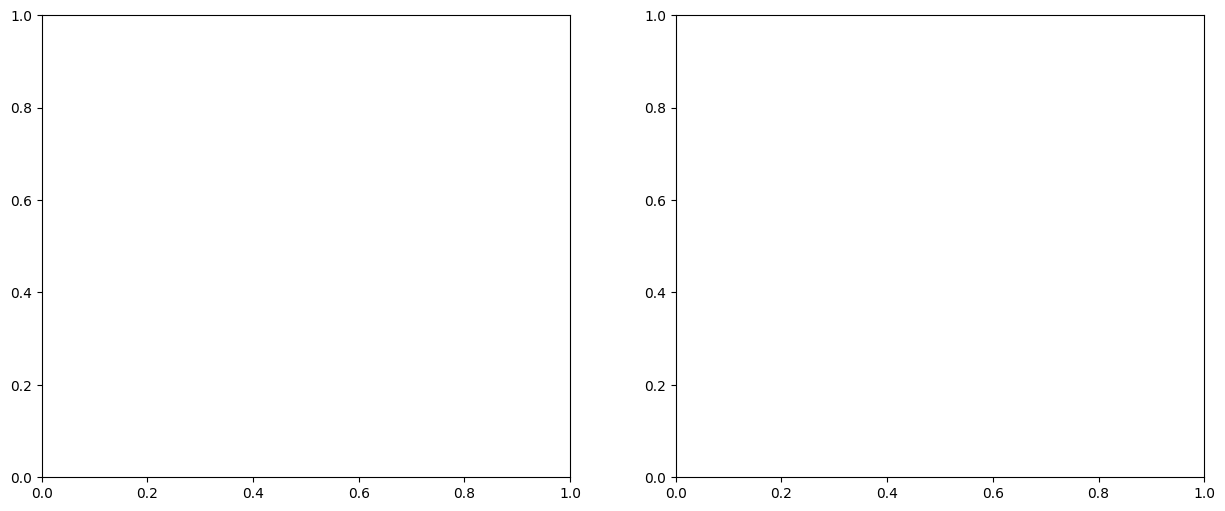

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

In [10]:
theta_range = np.linspace(-1, 8, 100)
landscape_loss = (theta_range - 3.5)**2 + 1
ax2.plot(theta_range, landscape_loss, 'k--', alpha=0.5, label='Loss Landscape')

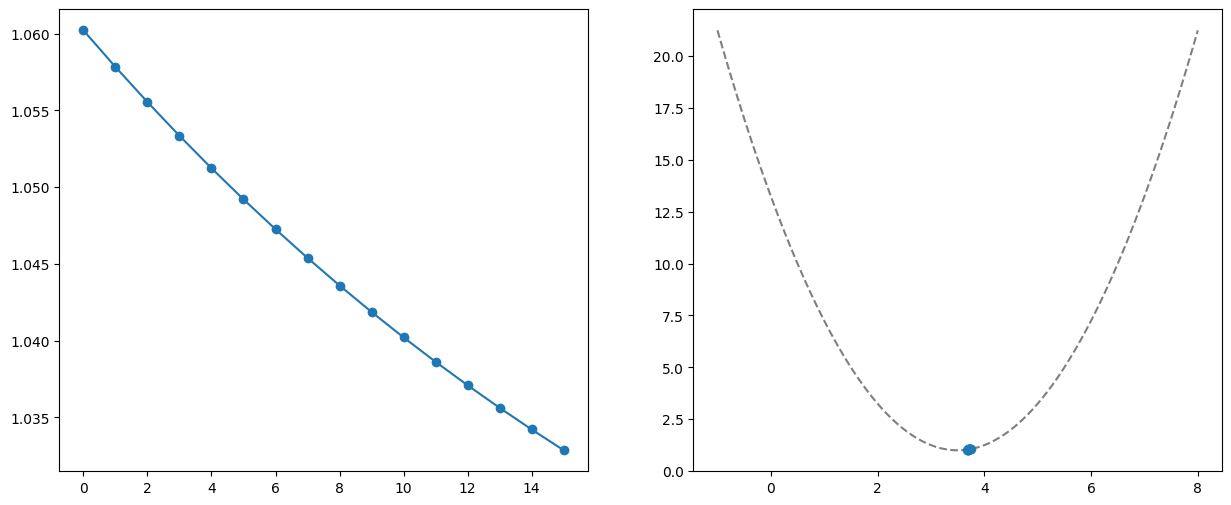

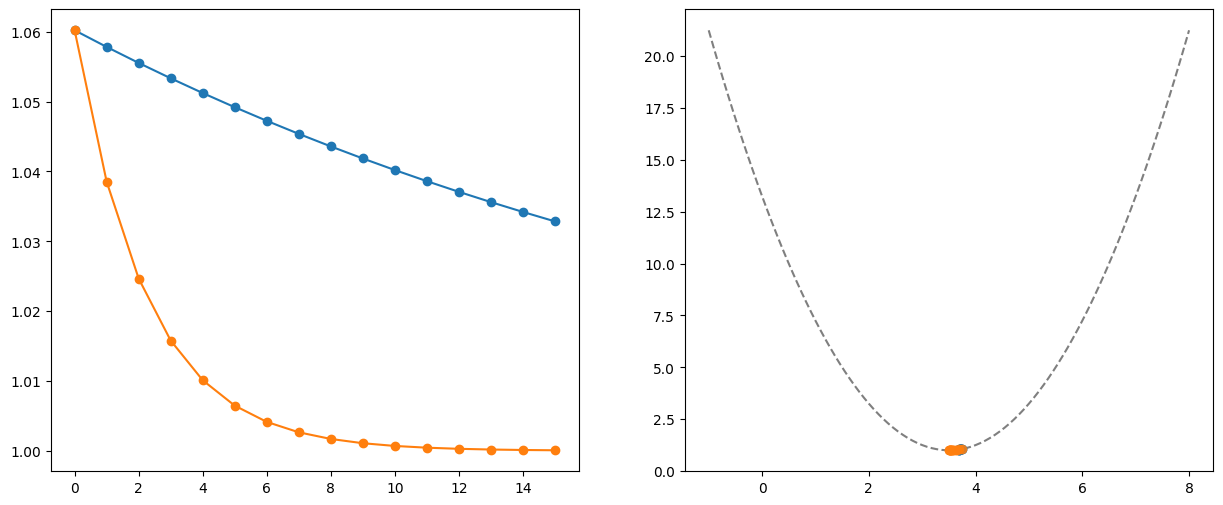

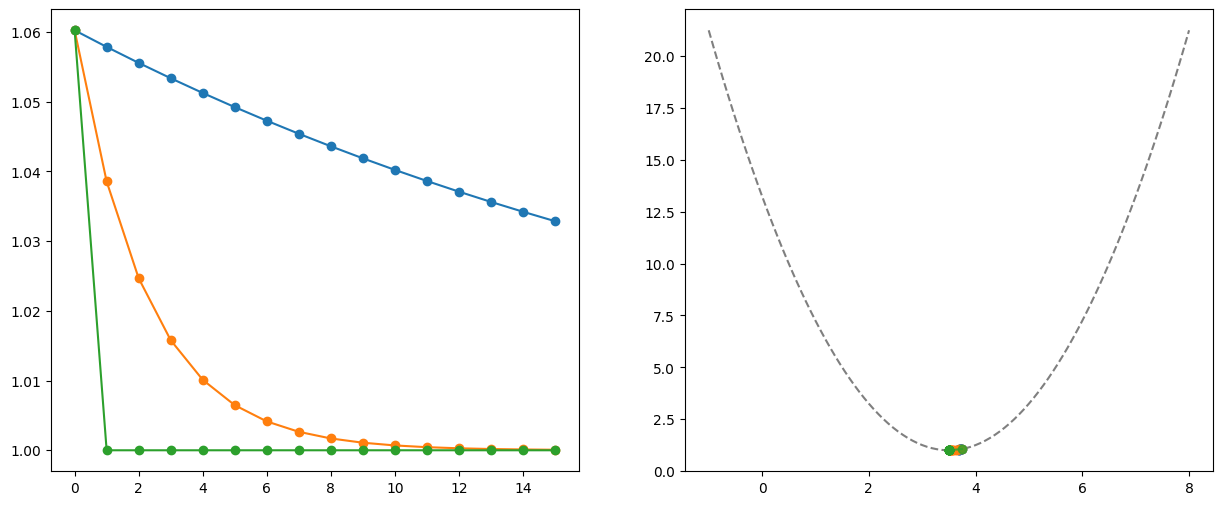

In [11]:
for lr in learning_rates:
    theta = start_theta
    lr_thetas = []
    lr_losses = []
    
    for i in range(iterations + 1):
        loss = (theta - 3.5)**2 + 1
        gradient = 2 * (theta - 3.5)
        results.append({
            'iteration': i, 
            'theta': theta, 
            'loss': loss, 
            'gradient': gradient, 
            'learning_rate': lr
        })
        lr_thetas.append(theta)
        lr_losses.append(loss)
        theta -= lr * gradient
    ax1.plot(range(iterations + 1), lr_losses, marker='o', label=f'LR = {lr}')
    ax2.plot(lr_thetas, lr_losses, marker='o', alpha=0.8, label=f'LR = {lr}')
    display(fig)

In [12]:
df = pd.DataFrame(results)
pd.set_option('display.max_rows', None) 
print(df.to_string(index=False))

 iteration    theta     loss  gradient  learning_rate
         0 3.745401 1.060222  0.490802           0.01
         1 3.740493 1.057837  0.480986           0.01
         2 3.735683 1.055547  0.471367           0.01
         3 3.730970 1.053347  0.461939           0.01
         4 3.726350 1.051234  0.452700           0.01
         5 3.721823 1.049206  0.443646           0.01
         6 3.717387 1.047257  0.434774           0.01
         7 3.713039 1.045386  0.426078           0.01
         8 3.708778 1.043588  0.417557           0.01
         9 3.704603 1.041862  0.409205           0.01
        10 3.700511 1.040205  0.401021           0.01
        11 3.696500 1.038612  0.393001           0.01
        12 3.692570 1.037083  0.385141           0.01
        13 3.688719 1.035615  0.377438           0.01
        14 3.684945 1.034205  0.369889           0.01
        15 3.681246 1.032850  0.362491           0.01
         0 3.745401 1.060222  0.490802           0.10
         1 3.696321 1.038542

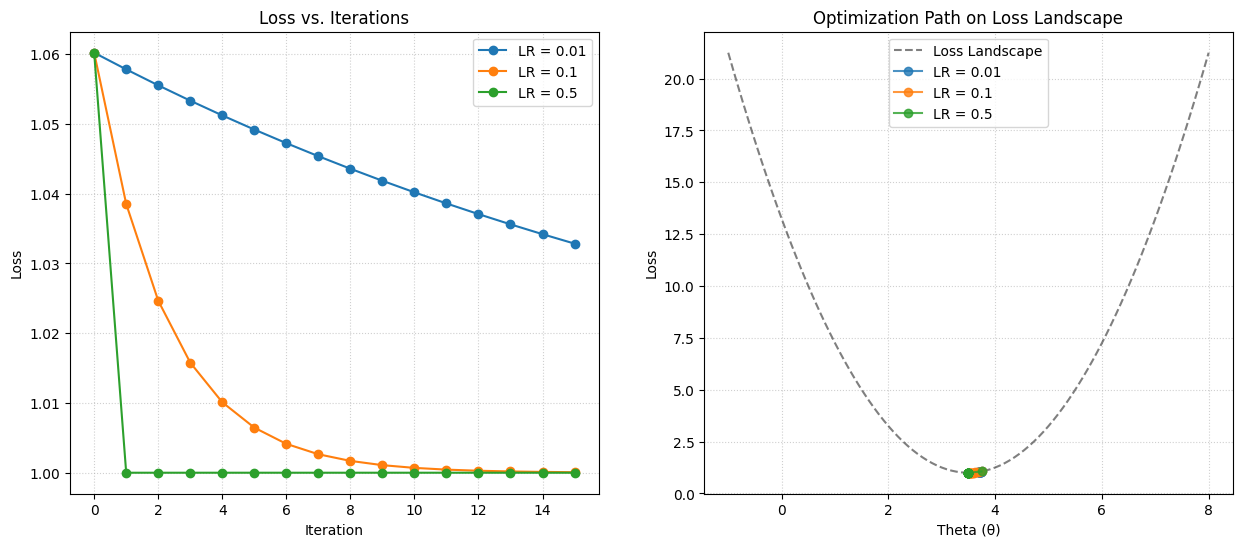

<Figure size 640x480 with 0 Axes>

In [13]:
ax1.set_title('Loss vs. Iterations', fontsize=12)
ax1.set_xlabel('Iteration', fontsize=10)
ax1.set_ylabel('Loss', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()
ax2.set_title('Optimization Path on Loss Landscape', fontsize=12)
ax2.set_xlabel('Theta (θ)', fontsize=10)
ax2.set_ylabel('Loss', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()
plt.tight_layout()
display(fig)
plt.show()

Comparison of Learning Rates & Convergence Behavior

By observing the loss curves and iteration tables, we can identify three distinct behaviors based on the learning rate multiplier:

1. Lower Learning Rate ($\alpha = 0.1$): Smooth but Slow Convergence

    $\theta$ moves strictly in one direction toward the minimum ($3.5$). The gradient steadily approaches $0$.

    It is highly stable and will not overshoot. However, it requires significantly more iterations to converge (Loss is still $1.0123$ after 15 steps).

2. Optimal/Moderate Learning Rate ($\alpha = 0.4$): Fast Convergence

    The parameter drops rapidly toward the minimum without overshooting heavily.

    It reaches the global minimum ($\text{Loss} = 1.0$) by iteration 5. This represents an ideal step size for this specific curvature.

3. Higher Learning Rate ($\alpha = 0.85$): Oscillating Convergence

    The step size is so large that $\theta$ constantly jumps over the minimum, bouncing from one side of the parabola to the other (e.g., $0.37 \rightarrow 5.68 \rightarrow 1.96$).

    Because the learning rate is $< 1.0$, the oscillations gradually dampen, and it eventually converges. However, it takes a highly inefficient "zig-zag" path. (Note: If the LR were $\ge 1.0$, it would diverge into infinity).